In [8]:
# Re-run after state reset

# Parse the provided log format and plot each metric over time (Train vs Valid)
# - Uses matplotlib (no seaborn), each chart in its own figure
# - Saves figures to /mnt/data and shows them inline
# - Displays a parsed DataFrame for inspection
import re
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from glob import glob
import PIL.Image as Image

In [9]:
# import sys
# from pathlib import Path
# __abs_path__ = str(Path.cwd().parents[0].absolute())
# __utils_path__ = f'{__abs_path__}/utils'

# for __util_path__ in [__abs_path__, __utils_path__]:
#     if not __util_path__ in sys.path:
#         sys.path+=[__util_path__]
# from utils.matplotlib_rnd import (
#     render_mesh_diff,
#     plot_image_array
# )
# sys.path = list(set(sys.path))
# import pickle
# import numpy as np

# M_SCALE = 0.68
# with open(f"/data/sihun/pca/VOCA-COMA/voca_templates.pkl",'rb') as f:
#     mesh = pickle.load(f)
    
# FRAME=100
# FRAME=270
# # FRAME=590
# # FRAME=820
# # FRAME=840
# FRAME=1256
# FRAME=2180
# # FRAME=3500
# # FRAME=3620

# # FRAME=2680
# # FRAME=0
# # GT = np.load(f'../eval_CBD/GT_coma/{FRAME:06d}.npy')
# # verts = np.load(f'../eval_CBD/2025-10-21-21-00-46-NGBCv5-eval/coma/verts/{FRAME:06d}.npy')
# # verts = np.load(f'../eval_CBD/2025-10-21-21-00-34-NGBCv5-eval/coma/verts/{FRAME:06d}.npy')
# v_list=[ 
#     np.load(f'../eval_CBD/GT_coma/{FRAME:06d}.npy'),
#     np.load(f'../eval_CBD/2025-10-21-21-00-34-NGBCv5-eval/coma/verts/{FRAME:06d}.npy'), # 1 1 relu
#     np.load(f'../eval_CBD/2025-10-21-21-00-46-NGBCv5-eval/coma/verts/{FRAME:06d}.npy'), # 1 0 relu
#     np.load(f'../eval_CBD/2025-10-21-21-07-13-NGBCv5-eval/coma/verts/{FRAME:06d}.npy'), # 1 2 relu
#     np.load(f'../eval_CBD/2025-10-21-21-24-21-NGBCv5-eval/coma/verts/{FRAME:06d}.npy'), # 1 1 softplus
#     np.load(f'../eval_CBD/2025-10-21-21-28-38-NGBCv5-eval/coma/verts/{FRAME:06d}.npy'), # 1 1 none
#     np.load(f'../eval_CBD/2025-10-21-21-39-27-NGBCv5-eval/coma/verts/{FRAME:06d}.npy'), # 1 1 relu     softPOU
# ]
# v_list=[v * M_SCALE for v in v_list]
# f_list=[ mesh['face']]*len(v_list)
# SIZE=2

# # print('|            GT             |           Base           |         Equation 8         |         Equation 9         |         w/softplus         |        no activation        |           softPOU          ')
# print('|            GT             |           Base           |          displace          |          matrix         |         w/softplus         |        no activation        |           softPOU          ')
# print('|            GT             |           4.8540E-04           |          5.1293E-04          |          5.7707E-04         |         9.9225E-04         |        3.6882E-04        |           4.2220E-04          ')
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-10,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"_tmp/train", 
#     name=f"test", save=False
# )

In [10]:
pat = re.compile(
    r"""
    ^\[(?P<epoch>\d+)\/(?P<epoch_max>\d+)\]      # [cur/max]
    \[(?P<iter>\d+)\]                             # [iter]
    \[(?P<phase>Train|Valid)\]\s+                # [phase]
    recon:\s+(?P<recon>[0-9.eE+\-]+)\s+
    exp-z:\s+(?P<exp_z>[0-9.eE+\-]+)\s+
    exp-v:\s+(?P<exp_v>[0-9.eE+\-]+)\s+
    shape:\s+(?P<shape>[0-9.eE+\-]+)\s+
    total:\s+(?P<total>[0-9.eE+\-]+)\s*
    $
    """,
    re.VERBOSE
)

pat2 = re.compile(
    r"""
    ^\[(?P<epoch>\d+)\/(?P<epoch_max>\d+)\]      # [cur/max]
    \[(?P<iter>\d+)\]                             # [iter]
    \[(?P<phase>Train|Valid)\]\s+                # [phase]
    recon-def:\s+(?P<recon_def>[0-9.eE+\-]+)\s+
    recon-neu:\s+(?P<recon_neu>[0-9.eE+\-]+)\s+
    exp-z:\s+(?P<exp_z>[0-9.eE+\-]+)\s+
    exp-v:\s+(?P<exp_v>[0-9.eE+\-]+)\s+
    shape:\s+(?P<shape>[0-9.eE+\-]+)\s+
    total:\s+(?P<total>[0-9.eE+\-]+)\s*
    $
    """,
    re.VERBOSE
)


pat3 = re.compile(
    r"""
    ^\[(?P<epoch>\d+)\/(?P<epoch_max>\d+)\]      # [cur/max]
    \[(?P<iter>\d+)\]                             # [iter]
    \[(?P<phase>Train|Valid)\]\s+                # [phase]
    recon-def:\s+(?P<recon_def>[0-9.eE+\-]+)\s+
    recon-neu:\s+(?P<recon_neu>[0-9.eE+\-]+)\s+
    exp-z:\s+(?P<exp_z>[0-9.eE+\-]+)\s+
    exp-v:\s+(?P<exp_v>[0-9.eE+\-]+)\s+
    shape:\s+(?P<shape>[0-9.eE+\-]+)\s+
    lag:\s+(?P<lag>[0-9.eE+\-]+)\s+
    dist:\s+(?P<dist>[0-9.eE+\-]+)\s+
    total:\s+(?P<total>[0-9.eE+\-]+)\s*
    $
    """,
    re.VERBOSE
)


pat4 = re.compile(
    r"""
    ^\[(?P<epoch>\d+)\/(?P<epoch_max>\d+)\]      # [cur/max]
    \[(?P<iter>\d+)\]                             # [iter]
    \[(?P<phase>Train|Valid)\]\s+                # [phase]
    recon-def:\s+(?P<recon_def>[0-9.eE+\-]+)\s+
    recon-neu:\s+(?P<recon_neu>[0-9.eE+\-]+)\s+
    exp-z:\s+(?P<exp_z>[0-9.eE+\-]+)\s+
    exp-v:\s+(?P<exp_v>[0-9.eE+\-]+)\s+
    shape:\s+(?P<shape>[0-9.eE+\-]+)\s+
    lag:\s+(?P<lag>[0-9.eE+\-]+)\s+
    dist:\s+(?P<dist>[0-9.eE+\-]+)\s+
    norm-def:\s+(?P<norm_def>[0-9.eE+\-]+)\s+
    norm-neu:\s+(?P<norm_neu>[0-9.eE+\-]+)\s+
    total:\s+(?P<total>[0-9.eE+\-]+)\s*
    $
    """,
    re.VERBOSE
)

In [11]:
def parse_log_file(path: str | Path, as_delta: bool = False, new=False, has_nrm=False) -> pd.DataFrame:
    rows = []
    ppat = pat2 if 'NGBCv' in path else pat

    if new:
        ppat = pat3
    if has_nrm:
        ppat = pat4
    
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = ppat.match(line)
            if not m:
                if new:
                    m = pat2.match(line)
                    if not m:
                        continue
                if has_nrm:
                    m = pat2.match(line)
                    if not m:
                        continue
                else:
                    m = pat2.match(line)
                    if not m:
                        continue
            g = m.groupdict()
            
            tmp_dict = {}
            for k,v in g.items():
                if k in ["epoch", "epoch_max", "iter"]:
                    v = int(v)
                elif k == "phase":
                    pass
                else:
                    v = float(v)
                tmp_dict[k]=v
            rows.append(tmp_dict)
    df = pd.DataFrame(rows)
    if df.empty:
        print('df empty?!')
        return df
    
    phase_key = {"Train": 0, "Valid": 1}
    df["phase_key"] = df["phase"].map(phase_key)
    df = df.sort_values(["epoch", "iter", "phase_key"]).reset_index(drop=True)
    
    df["x"] = np.nan
    for phase in df["phase"].unique():
        dph = df[df["phase"] == phase]
        for ep in dph["epoch"].unique():
            mask = (df["phase"] == phase) & (df["epoch"] == ep)
            iters = df.loc[mask, "iter"]
            denom = max(int(iters.max()), 1)
            df.loc[mask, "x"] = ep + iters.to_numpy() / float(denom)

    # per phase running index
    df["idx_phase"] = 0
    for phase in df["phase"].unique():
        mask = df["phase"] == phase
        df.loc[mask, "idx_phase"] = np.arange(mask.sum())
    
    if as_delta:
        keys = ["recon", "recon-def","recon-neu","shape", "exp_z", "exp_v", "total"]
        df[keys] = (
            df.groupby(["phase", "epoch"], sort=False)[keys]
              .diff()
              .fillna(0.0)
        )

    df = df.drop(columns=["phase_key"])
    return df
    
# ------------------------------
# 3) Plot helpers
# ------------------------------

def plot_metric(df: pd.DataFrame, metric: str, x_key: str = "x",
                yscale: str = "symlog", linthresh: float = 1e-12,
                save_dir: str | Path = "./_tmp/log_vis",
                mode: int = 0,
               ):
    """
    yscale:
      - 'linear': ordinary linear
      - 'log': log10 (only positive values)
      - 'symlog': safe around zero (recommended when metric can be zero)
    linthresh: symlog linear range half-width around 0.
    """
    if df.empty:
        print(f"No data to plot for metric '{metric}'"); 
        return None

    fig = plt.figure(figsize=(7, 4.5))
    ax = fig.add_subplot(111)

    
    if mode == 0:
        phases = ["Train"]
    elif mode == 1:
        phases = ["Valid"]
    else:
        phases = ["Train", "Valid"]
        
    for phase in phases:
        d = df[df["phase"] == phase]
        if d.empty:
            continue
        ax.plot(d[x_key].to_numpy(), d[metric].to_numpy(), label=phase, linewidth=1.8)

    # Choose y-scale
    if yscale == "log":
        # guard: ensure positive
        ymin = df[metric].replace(0, np.nan).min(skipna=True)
        if not np.isfinite(ymin) or ymin <= 0:
            # fallback safely to symlog if non-positive present
            ax.set_yscale("symlog", linthresh=linthresh)
        else:
            ax.set_yscale("log")
    elif yscale == "symlog":
        ax.set_yscale("symlog", linthresh=linthresh)
    else:
        ax.set_yscale("linear")

    ax.set_title(f"{metric} over time ({yscale})")
    ax.set_xlabel(x_key)
    ax.set_ylabel(metric)
    ax.grid(True, which="both", alpha=0.4)
    ax.legend()

    save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"logplot_{metric}_{yscale}.png"
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    return str(out_path)

def plot_all_metrics_subfig(
        df: pd.DataFrame,
        metrics=["recon", "exp_z", "exp_v", "shape", "total"],
        x_key="x",
        yscale="symlog",          # 'linear' | 'log' | 'symlog'
        linthresh=1e-8,           # for symlog
        ncols=2,
        figsize=(12, 9),
        mode: int = 0,
        save_path: str | Path | None = "./_tmp",
    ):
    assert not df.empty, "Empty dataframe"

    n = len(metrics)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    if isinstance(axes, np.ndarray):
        axes = axes.ravel()
    else:
        axes = [axes]
    
    if mode == 0:
        phases = ["Train"]
    elif mode == 1:
        phases = ["Valid"]
    else:
        phases = ["Train", "Valid"]
        
    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Train/Valid
        for phase in phases:
            d = df[df["phase"] == phase]
            if d.empty:
                continue
            ax.plot(d[x_key].to_numpy(), d[metric].to_numpy(), label=phase, alpha=0.5, linewidth=1.6)
        
        if yscale == "log":
            ymin = df[metric].replace(0, np.nan).min(skipna=True)
            if not np.isfinite(ymin) or ymin <= 0:
                ax.set_yscale("symlog", linthresh=linthresh)
            else:
                ax.set_yscale("log")
        elif yscale == "symlog":
            ax.set_yscale("symlog", linthresh=linthresh)
        else:
            ax.set_yscale("linear")

        ax.set_title(metric)
        ax.set_xlabel(x_key)
        ax.grid(True, which="both", alpha=0.35)
        ax.legend(fontsize=9)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved -> {save_path}")
    return fig

Saved -> _tmp


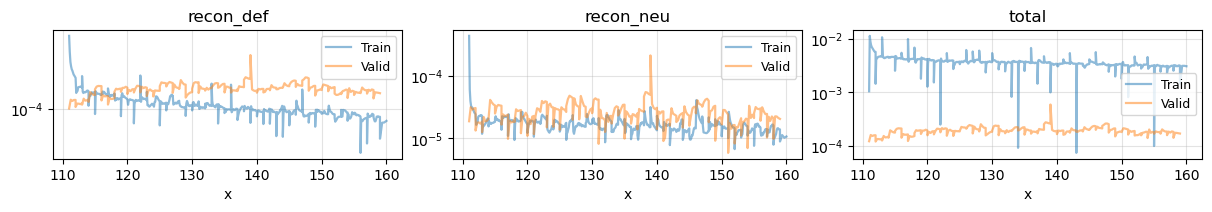

In [24]:
# log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-09-08-13-21-05-NGBC" # -> as_delta=True
# log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-09-10-11-20-25-NGBC"
# log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-09-11-15-26-03-NGBC"
# log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-10-22-22-30-30-NGBCv5"
log_path = "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-03-14-56-32-NGBCv5"

df = parse_log_file(log_path+"/log.txt", as_delta=False)
# df = parse_log_file(log_path+"/log.txt", as_delta=True)

# # paths = {}
# # # for metric in ["recon", "exp_z", "exp_v", "shape", "total"]:
# # for metric in ["recon", "shape", "total"]:
# #     p = plot_metric(df, metric, x_key="x", save_dir="/_tmp/data")
# #     if p is not None:
# #         paths[metric] = p

# _ = plot_metric(df, "recon", x_key="x", mode=1)         # epoch+iter 정규화 축
# _ = plot_metric(df, "shape", x_key="x", mode=1)         # epoch+iter 정규화 축
# _ = plot_metric(df, "total", x_key="x", mode=1)
# # 또는
# #_ = plot_metric(df, "total", x_key="idx_phase")  # phase별 누적 인덱스 축

# fig = plot_all_metrics_subfig(
#     df, 
#     # yscale="log",
#     yscale="symlog",
#     metrics=["recon", "shape", "total"],
#     ncols=2, figsize=(12, 9), mode=-1,
#     save_path="logplots_all_metrics.png"
# )
# plt.show()


fig = plot_all_metrics_subfig(
    df, 
    # yscale="log",
    yscale="symlog",
    # metrics=["recon", "shape", "total"],
    metrics=["recon_def", "recon_neu", "total"],
    ncols=3, figsize=(12, 2), 
    mode=-1,
    # mode=1,
    # mode=0,
    #save_path="logplots_all_metrics.png"
)
plt.show()


Saved -> _tmp


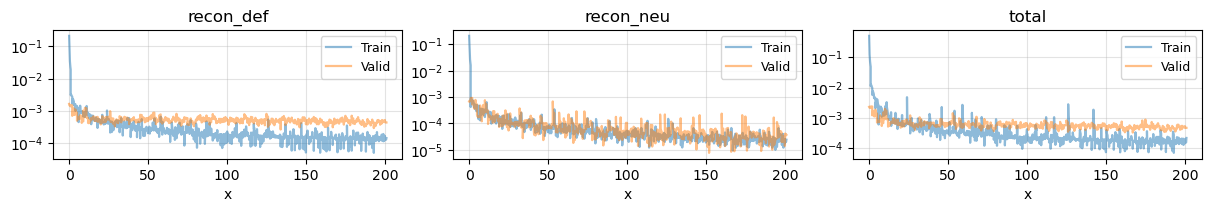

Saved -> _tmp


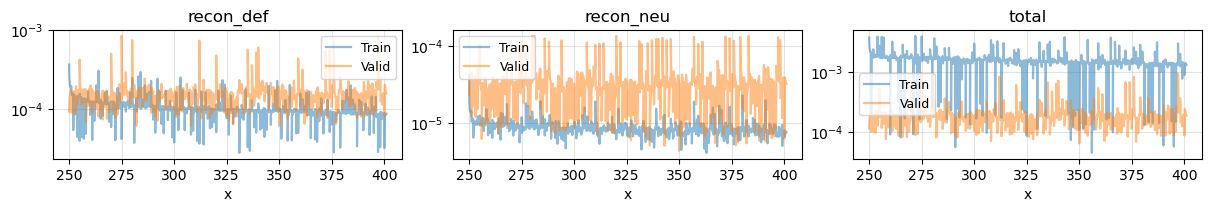

Saved -> _tmp


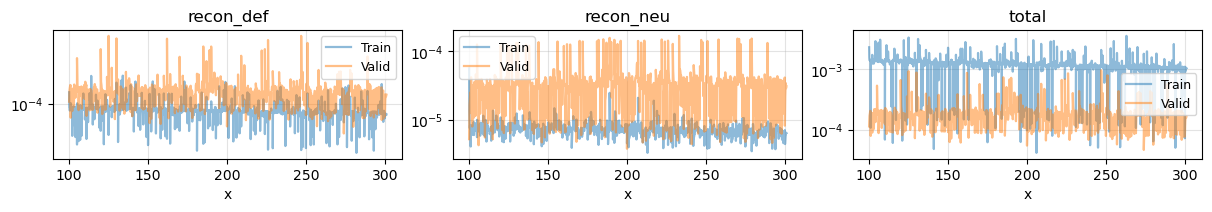

Saved -> _tmp


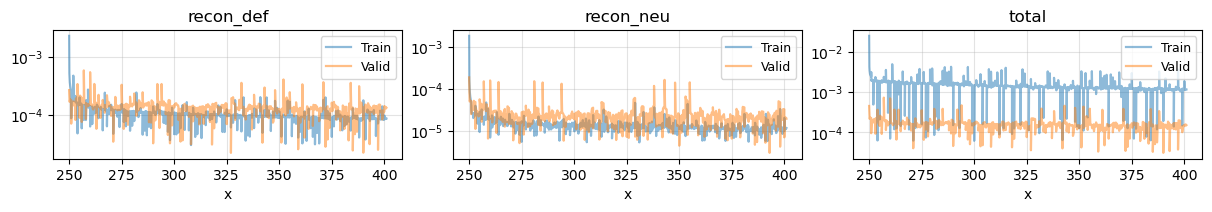

Saved -> _tmp


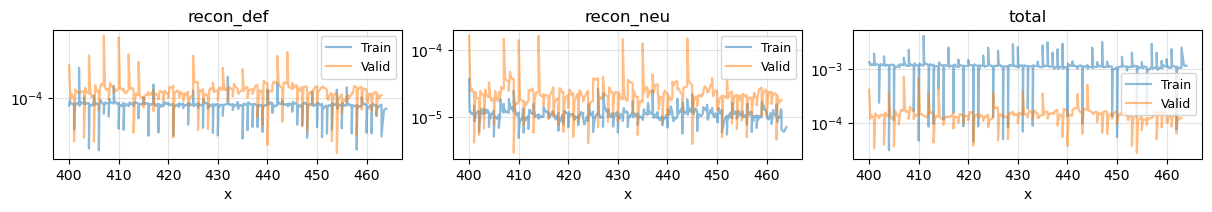

In [5]:
log_path_list= [
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-10-09-02-04-49-NGBCv5",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-10-22-22-30-30-NGBCv5",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-10-31-16-58-12-NGBCv5",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-03-14-56-32-NGBCv5",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-05-16-32-53-NGBCv5",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-08-22-53-46-NGBCv5",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-09-21-21-43-NGBCv5",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-11-01-01-20-NGBCv5",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-14-13-08-43-NGBCv5",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD/2025-11-16-22-06-42-NGBCv5",
]
for log_path in log_path_list:
    df = parse_log_file(log_path+"/log.txt", as_delta=False)
    fig = plot_all_metrics_subfig(
        df, 
        # yscale="log",
        yscale="symlog",
        # metrics=["recon", "shape", "total"],
        metrics=["recon_def", "recon_neu", "total"],
        ncols=3, figsize=(12, 2), 
        mode=-1,
        # mode=1,
        # mode=0,
        #save_path="logplots_all_metrics.png"
    )
    plt.show()


Saved -> _tmp


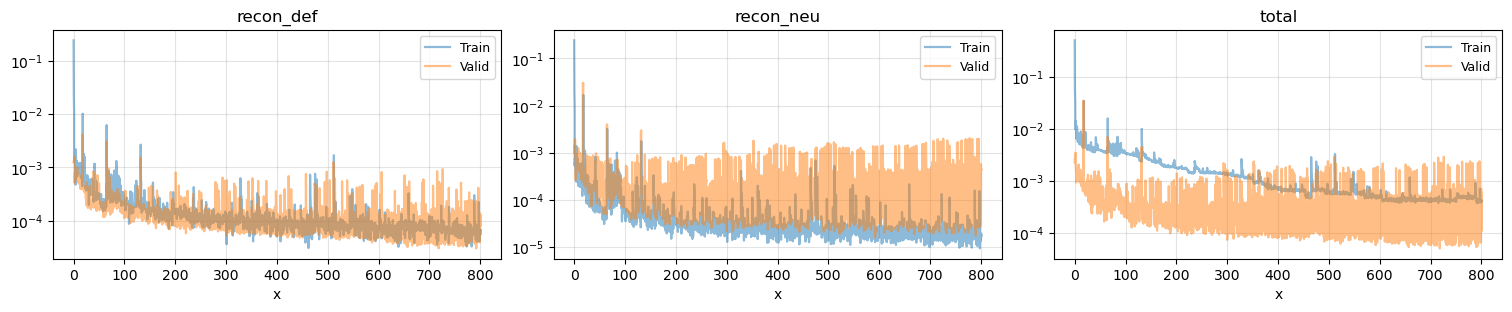

Saved -> _tmp


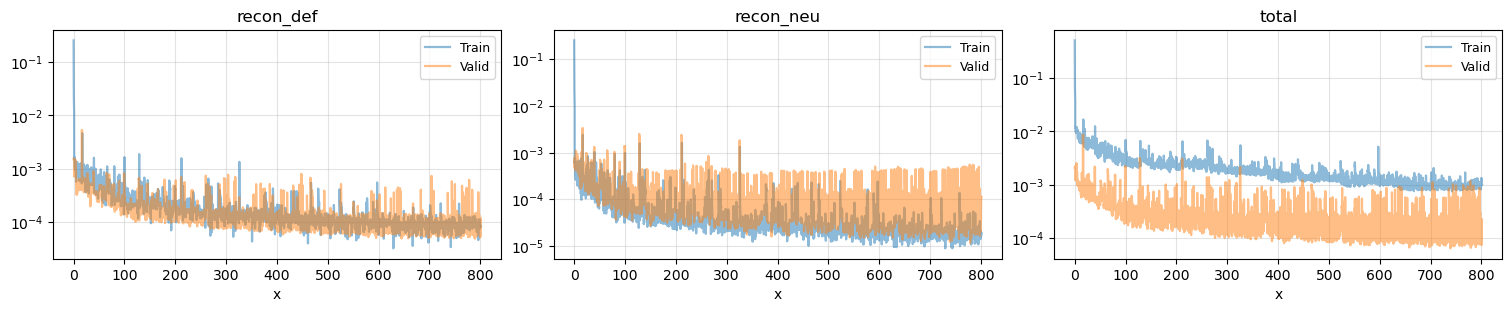

Saved -> _tmp


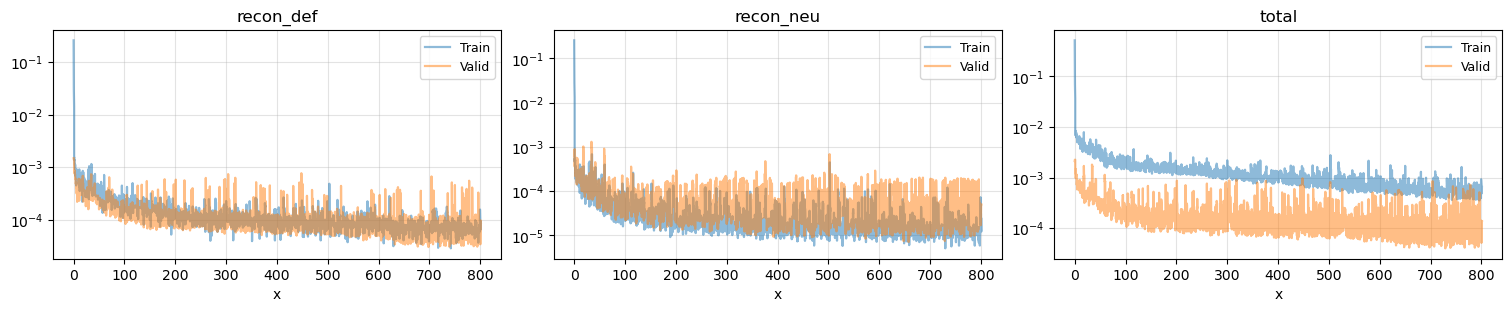

Saved -> _tmp


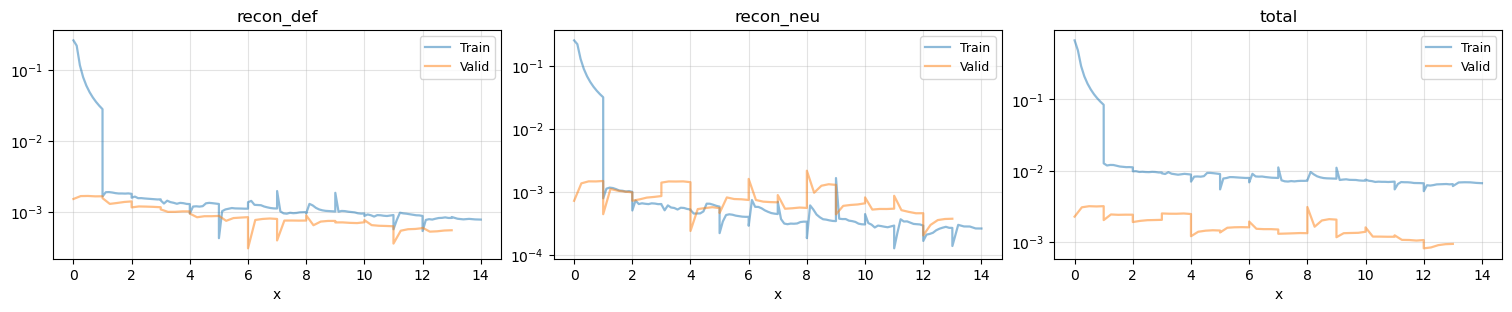

In [18]:
# Yscale="log"
Yscale="symlog"
figsize=(15, 3)
log_path_list1= [
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-11-17-14-08-46-NGBCv1",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-11-18-13-09-15-NGBCv1",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-11-20-09-48-21-NGBCv1",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-11-21-12-50-24-NGBCv1",
    # "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-11-26-14-46-32-NGBCv1", # normal loss
]
for log_path in log_path_list1:
    df = parse_log_file(log_path+"/log.txt", as_delta=False,new=True)
    fig = plot_all_metrics_subfig(
        df, 
        # yscale="log",
        yscale=Yscale,
        # metrics=["recon", "shape", "total"],
        metrics=["recon_def", "recon_neu", "total"],
        # metrics=["recon_def"],
        ncols=3, figsize=figsize, 
        mode=-1,
        # mode=1,
        # mode=0,
        #save_path="logplots_all_metrics.png"
    )
    plt.show()

log_path_list2= [
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-11-26-14-46-32-NGBCv1", # normal loss
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-12-04-00-29-05-NGBCv1",
    "/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-12-10-11-18-32-NGBCv1",
]
for log_path in log_path_list2:
    df = parse_log_file(log_path+"/log.txt", as_delta=False,has_nrm=True)
    fig = plot_all_metrics_subfig(
        df, 
        yscale=Yscale,
        # yscale="symlog",
        # yscale="linear",
        # metrics=["recon", "shape", "total"],
        metrics=["recon_def", "recon_neu", "total"],
        # metrics=["recon_def"],
        ncols=3, figsize=figsize, 
        mode=-1,
        # mode=1,
        # mode=0,
        #save_path="logplots_all_metrics.png"
    )
    plt.show()

/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-12-04-00-29-05-NGBCv1/img/train/mesh/800_0849.png
/source/sihun/NeuralFacialAnimation/ckpts_CBD3/2025-12-04-00-29-05-NGBCv1/img/valid/mesh/800_0079.png


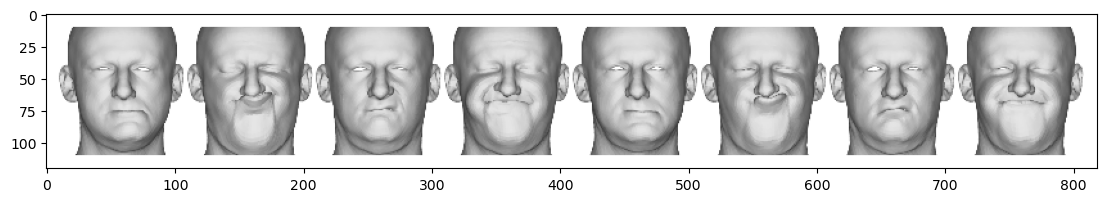

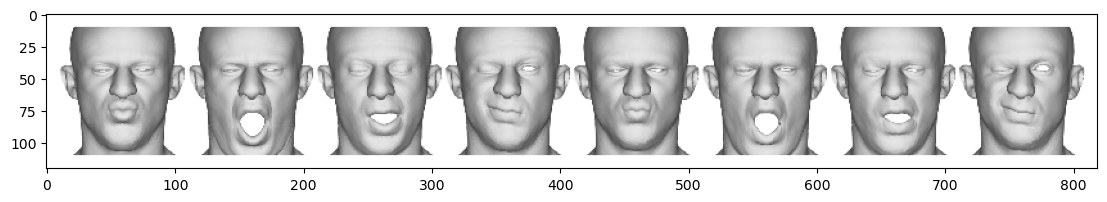

In [17]:
from PIL import Image
from glob import glob

# log_path = log_path_list1[-1]
log_path = log_path_list2[-1]
NUM = -2

train_img_list =sorted( glob(f"{log_path}/img/train/mesh/*.png"))
asd = train_img_list[NUM]
print(asd)
plt.figure(figsize = (20,2))
plt.imshow(np.array(Image.open(asd)))

val_img_list =sorted( glob(f"{log_path}/img/valid/mesh/*.png"))
asd = val_img_list[NUM]
print(asd)
plt.figure(figsize = (20,2))
plt.imshow(np.array(Image.open(asd)))

In [90]:
import torch
B=2
F=1
eps=1e-12
C=3
D=3
H=5
asd = torch.rand(B, H*H,3)
print(asd)
mat = torch.zeros((B,4,4))
mat[:,:3,:3] = torch.rand(3,3)
mat[:,:3,3]=torch.ones(3)
print(mat.shape)

asd = torch.cat((asd, torch.ones(B,H*H,1)),dim=-1)
# asd2 = asd @ mat
asd2 = torch.bmm(asd, mat)            # (BF, C+1, C+1)
print(mat)

print(asd2.shape)



X = asd.transpose(1, 2)  # (BF, C+1, P)
Y = asd2.transpose(1, 2)
print(X.shape, Y.shape,'(BF, C+1, P)')
# Y = A2_h
XXT = torch.bmm(X, X.transpose(1, 2))  # (BF, C+1, C+1)
print(XXT.shape)
I = torch.eye(C + 1, device=X.device).unsqueeze(0).expand(B * F, -1, -1)
XXT_inv = torch.linalg.inv(XXT + eps * I)

YXT = torch.bmm(Y, X.transpose(1, 2))  # (BF, C+1, C+1)
T = torch.bmm(YXT, XXT_inv)            # (BF, C+1, C+1)
T=T.transpose(2,1)
# Step 4: reshape back to (B, F, C+1, C+1)

print(T.shape)
print(T)

tensor([[[0.3541, 0.0700, 0.2201],
         [0.3565, 0.5279, 0.9270],
         [0.3117, 0.9799, 0.6244],
         [0.6742, 0.5967, 0.2275],
         [0.4049, 0.9177, 0.4684],
         [0.2328, 0.6491, 0.4057],
         [0.2812, 0.2777, 0.0854],
         [0.8214, 0.3226, 0.8773],
         [0.1291, 0.2444, 0.0075],
         [0.0311, 0.4877, 0.2511],
         [0.3096, 0.7971, 0.2746],
         [0.6985, 0.7997, 0.0455],
         [0.6531, 0.7927, 0.5518],
         [0.5063, 0.7056, 0.7981],
         [0.6822, 0.0803, 0.1910],
         [0.3253, 0.9146, 0.2154],
         [0.8328, 0.2518, 0.1532],
         [0.3830, 0.7369, 0.2439],
         [0.3542, 0.8127, 0.4209],
         [0.6748, 0.8016, 0.8215],
         [0.7594, 0.4588, 0.6574],
         [0.7461, 0.5008, 0.1927],
         [0.8739, 0.5120, 0.9344],
         [0.7364, 0.0938, 0.1630],
         [0.3203, 0.0472, 0.8882]],

        [[0.4433, 0.0037, 0.8333],
         [0.1760, 0.0845, 0.0469],
         [0.0730, 0.2811, 0.8612],
         [0.8601, 